In [30]:
# sum of square for error function (SSE)

import numpy as np

def sum_square_error(y, t):
    return 0.5 * np.sum((y-t)**2) # We multiply  0.5 to cancel 2 that appears during differentiation(backward propagation)

In [31]:
t = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0])

y = np.array([0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0])
print(sum_square_error(y, t))


# same values but order is changed
y = np.array([0.1, 0.05, 0.05, 0.0, 0.6, 0.1, 0.0, 0.1, 0.0])
print(sum_square_error(y, t))

0.09750000000000003
0.6475


In [32]:
# cross entropy error function (CEE)

import numpy as np

def corss_entropy_error(p, t):
    delta = 1e-7
    return -np.sum(t * np.log(p + delta))

In [33]:
t = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0])

y = np.array([0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0])
print(corss_entropy_error(y, t))


# same values but order is changed
y = np.array([0.1, 0.05, 0.05, 0.0, 0.6, 0.1, 0.0, 0.1, 0.0])
print(corss_entropy_error(y, t))

0.510825457099338
2.9957302735559908


In [34]:
# Mini Batch: a subset of the dataset


import sys
from pathlib import Path
sys.path.append(str((Path.cwd() / "..").resolve()))
from dataset.mnist import load_mnist
import numpy as np

# looad data
(x_train, t_train), (x_test, t_test) = load_mnist()
print(x_train.shape)
print(t_train.shape)



(60000, 784)
(60000,)


In [35]:
# random Mini Batch
train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]

In [36]:
# cross entropy error for batch

def corss_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(t * np.log(y + 1e-7)) / batch_size

In [37]:
a = np.array([3])
a.reshape(1, 1)

array([[3]])

## Why do we need loss function?

Accuracy gives us discrete outcomes like 34% and 35%, whereas the loss function provides continuous values that show how far predictions are from the true values. So, even small differences can elad to different continuous outcome.

However, there is one condition: we should use an activation funciton whose derivative is not zero.(the derivative of step function has zero)

# differentiation

In [38]:
def function_1(x):
    return x ** 2 + 2 * x + 1

In [39]:
for i in range(50, 1, -5):
    print(f"10^(-{i}): {(function_1(2 + 10**(-i))-function_1(2)) / 10**(-i)}")

10^(-50): 0.0
10^(-45): 0.0
10^(-40): 0.0
10^(-35): 0.0
10^(-30): 0.0
10^(-25): 0.0
10^(-20): 0.0
10^(-15): 5.329070518200751
10^(-10): 6.000000496442226
10^(-5): 6.000009999951316


As you can see too small float has percision loss issue. so recommend $10^{-10}$ as a delta

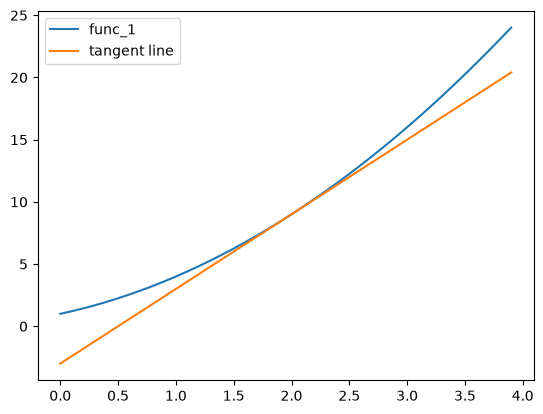

In [40]:
# tangent line of function_1 using derivative

import matplotlib.pyplot as plt
import numpy as np

X = np.arange(0, 4, 0.1)

#tangent line
# derivatice of function_1 when x = 2
slope = (function_1(2 + 10e-10)-function_1(2)) / 10e-10
tangent = slope * (X - 2) + function_1(2)

Y = function_1(X)

plt.plot(X, Y, label="func_1")
plt.plot(X, tangent, label="tangent line")
plt.legend()
plt.show()

In [41]:
# 2 variables function

def function_2(X):
    return X[0]**2 + X[1]**2

In [42]:
# numerical_gradient function for multiple variable function

def numerical_gradient(f, x): # X = [x, y]
    h = 10e-4

    grad = np.zeros_like(x)
    for idx in range(x.size):
        tmp = x[idx]

        x[idx] = tmp - h
        fxh1 = f(x)

        x[idx] = tmp + h
        fxh2 = f(x)

        grad[idx] = (fxh2 - fxh1) / (2*h)
        x[idx] = tmp

    return grad

In [43]:
numerical_gradient(function_2, np.array([2.0, 2.0]))

array([4., 4.])

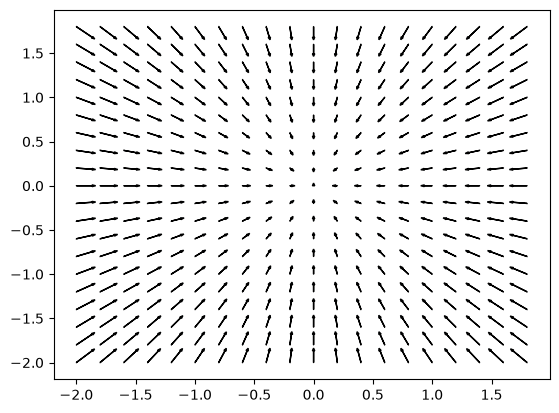

In [44]:
import matplotlib.pyplot as plt
import numpy as np

X1 = np.arange(-2, 2, 0.2)
X2 = np.arange(-2, 2, 0.2)

for x1Idx in range(X1.size):
    for x2Idx in range(X2.size):
        grads = -numerical_gradient(function_2, np.array([X1[x1Idx], X2[x2Idx]], dtype=np.float32)) / 30
        plt.arrow(X1[x1Idx], X2[x2Idx], grads[0], grads[1], head_width=0.02)
plt.show()

# gradient descent
- $\eta$: `learning rate`
$$
x_0 = x_0 - \eta\frac{\partial f}{\partial x_0}
$$
$$
x_1 = x_1 - \eta\frac{\partial f}{\partial x_1}
$$

In [45]:
def gradient_decsent(f, init_x, lr=0.1, step_num=100):
    xs = [init_x]
    x = init_x

    for i in range(step_num):
        x -= lr * numerical_gradient(f, x)
        xs.append(x.copy())

    return np.array(xs)

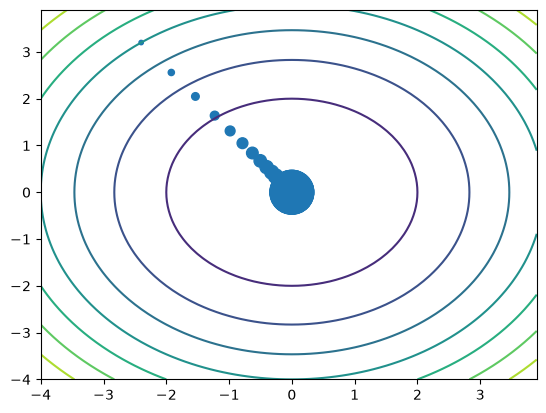

In [46]:
# calculation
grad_move = gradient_decsent(function_2, np.array([-3.0, 4.0]), lr=0.1)

# visualization

X = np.arange(-4, 4, 0.1)
Y = np.arange(-4, 4, 0.1)

X, Y = np.meshgrid(X, Y)

Z = function_2(np.array([X, Y]))

plt.contour(X, Y, Z)
plt.scatter(grad_move[:,0], grad_move[:,1], s=np.arange(grad_move.shape[0]) * 10)
plt.show()

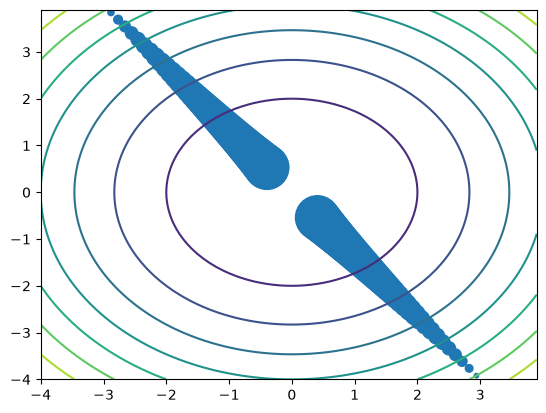

In [47]:
# calculation
grad_move = gradient_decsent(function_2, np.array([-3.0, 4.0]), lr=0.99)

# visualization

X = np.arange(-4, 4, 0.1)
Y = np.arange(-4, 4, 0.1)

X, Y = np.meshgrid(X, Y)

Z = function_2(np.array([X, Y]))

plt.contour(X, Y, Z)
plt.scatter(grad_move[:,0], grad_move[:,1], s=np.arange(grad_move.shape[0]) * 10)
plt.show()

# Apply to Neural Network

We can train Neural Network by tuning `weight` and `bias`. So we need to use numerical_gradient decsent on them. It's expressed like below.
- `W`: weight matrix
- `L`: loss function
$$
W = 
\begin{bmatrix}
w_{11} & w_{12} & w_{13}\\
w_{21} & w_{22} & w_{23}
\end{bmatrix},

\frac{\partial L}{\partial W} =
\begin{bmatrix}
\frac{\partial L}{\partial w_{11}} & \frac{\partial L}{\partial w_{12}} & \frac{\partial L}{\partial w_{13}}\\
\frac{\partial L}{\partial w_{11}} & \frac{\partial L}{\partial w_{22}} & \frac{\partial L}{\partial w_{23}}
\end{bmatrix}
$$

## Practice

Implement simpleNet class which `predict` and calculate `loss`

### Requirements
- make `__init__`, `predict`, `loss` functions
- use weight matrix which follows `normal distribution`
- use `softmax`, `cross_entropy_error` functions


In [52]:
# numerical_gradient function for multiple variable function

def numerical_gradient(f, x): # X = 2 dim array
    h = 10e-4

    grads = np.zeros_like(x)
    for idx in range(x.size):
        tmp = x.flat[idx]

        x.flat[idx] = tmp - h
        fxh1 = f(x)

        x.flat[idx] = tmp + h
        fxh2 = f(x)

        grads.flat[idx] = (fxh2 - fxh1) / (2*h)
        x.flat[idx] = tmp

    return grads

def cross_entropy_error(x, t):
    return -np.sum(t * np.log(x + 10e-10)) / x.shape[0]

def softmax(x):
    if x.ndim == 1:
        max_x = np.max(x)
        exp_x = np.exp(x-max_x)
        sum_exp_x = np.sum(exp_x)
        return exp_x / sum_exp_x 

    max_x = np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x-max_x)
    sum_exp_x = np.sum(exp_x, axis=1, keepdims=True)
    return exp_x / sum_exp_x 



In [53]:
class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2, 3)

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)

        return cross_entropy_error(y, t)

In [54]:
net = simpleNet()

In [55]:
x = np.array([0.6, 0.9])
y = net.predict(x)

print(y)

t = np.array([1, 0, 0])
loss = net.loss(x, t)

print(loss)

[ 0.45167291 -0.3092202  -0.55134228]
0.20217024176108167


In [56]:
# def f(W):
#     return net.loss(x, t)

f = lambda W: net.loss(x, t)

dW = numerical_gradient(f, net.W)
print(dW)

[[-0.09094998  0.0509535   0.03999648]
 [-0.13642498  0.07643026  0.05999472]]


# Two Layer Network

In [57]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [58]:
# Two Layer Network

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        self.params = {}
        self.params['W1'] = np.random.randn(input_size, hidden_size) * weight_init_std
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = np.random.randn(hidden_size, output_size) * weight_init_std
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        z1 = np.dot(x, W1) + b1
        a1 = sigmoid(z1)
        z2 = np.dot(a1, W2) + b2
        y = softmax(z2)

        return y

    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])

        return accuracy
    
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        for key in ('W1', 'b1', 'W2', 'b2'):
            grads[key] = numerical_gradient(loss_W, self.params[key])

        return grads


In [59]:
net = TwoLayerNet(784, 50, 10)

print(net.params['W1'].shape)
print(net.params['b1'].shape)
print(net.params['W2'].shape)
print(net.params['b2'].shape)

(784, 50)
(50,)
(50, 10)
(10,)


In [60]:
x = np.random.rand(100, 784)
y = net.predict(x)

print(y.shape)

t = np.random.rand(100, 10)
grads = net.numerical_gradient(x, t)

print(grads['W1'].shape)
print(grads['b1'].shape)
print(grads['W2'].shape)
print(grads['b2'].shape)


(100, 10)
(784, 50)
(50,)
(50, 10)
(10,)


# Implementing Mini Batch Training

In [61]:
import sys
from pathlib import Path
sys.path.append(str((Path.cwd() / "..").resolve()))
import numpy as np
from dataset.mnist import load_mnist


(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

loss_history = []

# hyper parameters
iters_num = 50
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

for i in range(iters_num):
    # Get Mini Batch
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # Get gradients
    grads = network.numerical_gradient(x_batch, t_batch)

    # Update params
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grads[key]

    # Records loss
    loss = network.loss(x_batch, t_batch)
    loss_history.append(loss)

    print(f"progress: {i+1} / {iters_num}    loss: {loss}")



progress: 1 / 50    loss: 2.2928492031778105
progress: 2 / 50    loss: 2.2994368994015435
progress: 3 / 50    loss: 2.3007263432744325
progress: 4 / 50    loss: 2.2904032823402383
progress: 5 / 50    loss: 2.3002668456122213
progress: 6 / 50    loss: 2.271164103776192
progress: 7 / 50    loss: 2.2959879962771104
progress: 8 / 50    loss: 2.291487945422025
progress: 9 / 50    loss: 2.300097825741185
progress: 10 / 50    loss: 2.2716997661156717
progress: 11 / 50    loss: 2.2799183446753966
progress: 12 / 50    loss: 2.2896685527001455
progress: 13 / 50    loss: 2.29950030435277
progress: 14 / 50    loss: 2.305297020866717
progress: 15 / 50    loss: 2.2865605783281584
progress: 16 / 50    loss: 2.3039972075709843
progress: 17 / 50    loss: 2.297061972137779
progress: 18 / 50    loss: 2.3019948940369783
progress: 19 / 50    loss: 2.2877342180650864
progress: 20 / 50    loss: 2.2948610616299887
progress: 21 / 50    loss: 2.2853720254248096
progress: 22 / 50    loss: 2.2913411554509087
prog

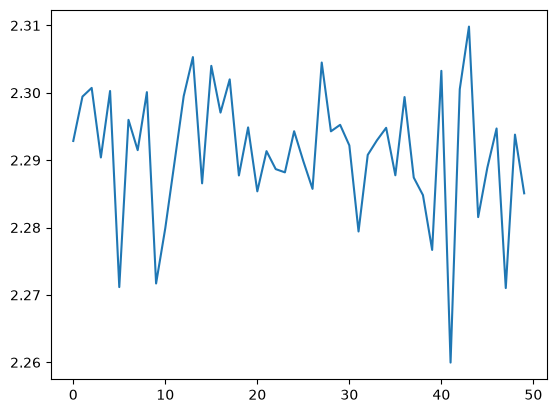

In [62]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.show()

### Limitation

With my computing resources, it takes too long to calculate with `numerical_gradient`.

# Epoch
an `epoch` is the one complete pass through the entire training dataset.

For example, if there are 10,000 training data points and the batch size is 100, one epoch consists of 100 iterations (or mini batch update)

The network proccesses all 10,000 training data points once during one epoch. After an epoch, we can evaluate the network's accuracy on the training or validation dataset.

In [ ]:
import sys
from pathlib import Path
sys.path.append(str((Path.cwd() / "..").resolve()))
import numpy as np
from dataset.mnist import load_mnist


(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

train_loss_list = []
train_acc_list = []
test_acc_list = []

# hyper parameters
iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

iter_per_epoch = max(train_size / batch_size, 1)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

for i in range(iters_num):
    # Get Mini Batch
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    # Get gradients
    grads = network.numerical_gradient(x_batch, t_batch)

    # Update params
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grads[key]

    # Records loss
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)

    print(f"progress: {i+1} / {iters_num}    loss: {loss}")

    # When iteration reach epoch
    if i % iter_per_epoch == 0:
        train_acc = net.accuracy(x_batch, t_batch)
        test_acc = net.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(f"train acc, test acc | {str(train_acc)}, {str(test_acc)}")



The reason calculating acc per epoch is save computing resouces to calculate acc.